<a href="https://colab.research.google.com/github/imxal/Remote-work-burnout-analysis/blob/main/remote_work_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git config --global user.name "imxal"
!git config --global user.email "satyal.laxmi999@gmail.com"

In [3]:
!ls /content

Remote-work-burnout-analysis  sample_data


In [4]:
!cp /content/Remote-work-burnout-analysis/

cp: missing destination file operand after '/content/Remote-work-burnout-analysis/'
Try 'cp --help' for more information.


In [1]:
!git clone https://github.com/imxal/Remote-work-burnout-analysis.git
!cp /content/*.ipynb Remote-work-burnout-analysis/
%cd Remote-work-burnout-analysis
!git add .
!git commit -m "Data Cleaning and EDA"
!git push

Cloning into 'Remote-work-burnout-analysis'...
cp: cannot stat '/content/*.ipynb': No such file or directory
/content/Remote-work-burnout-analysis
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@2a1b39a4b791.(none)')
error: src refspec refs/heads/main does not match any
error: failed to push some refs to 'https://github.com/imxal/Remote-work-burnout-analysis.git'


In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway


In [2]:
df = pd.read_csv('Remote_work_health_impact_2025.csv')
df.head()

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K


# Data Overview
This cell describes the dataset:

- check data types

- summary statistics

- check for missing values

In [17]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Survey_Date              3157 non-null   datetime64[ns]
 1   Age                      3157 non-null   int64         
 2   Gender                   3157 non-null   object        
 3   Region                   3157 non-null   object        
 4   Industry                 3157 non-null   object        
 5   Job_Role                 3157 non-null   object        
 6   Work_Arrangement         3157 non-null   object        
 7   Hours_Per_Week           3157 non-null   int64         
 8   Mental_Health_Status     2358 non-null   object        
 9   Burnout_Level            3157 non-null   object        
 10  Work_Life_Balance_Score  3157 non-null   int64         
 11  Physical_Health_Issues   2877 non-null   object        
 12  Social_Isolation_Score   3157 non-

,0
Survey_Date,0
Age,0
Gender,0
Region,0
Industry,0
Job_Role,0
Work_Arrangement,0
Hours_Per_Week,0
Mental_Health_Status,799
Burnout_Level,0


#Data Cleaning
- converting date
- Standardize categorical variables (work_type, preference)
- Remove impossible values (Hours_per_week > 80)


In [18]:
df['Survey_Date'] = pd.to_datetime(df['Survey_Date'], errors='coerce')


In [6]:
df['Work_Arrangement'] = df['Work_Arrangement'].str.lower().str.strip()
df['Burnout_Level']= df['Burnout_Level'].str.lower().str.strip()

In [7]:
df=df[df['Hours_Per_Week'] <= 80 ]

In [15]:
#convert burnout to numeric
burnout_mapping = {"low": 1, "medium": 2, "high": 3}
df['Burnout_score'] = df['Burnout_Level'].map(burnout_mapping)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Survey_Date              3157 non-null   object
 1   Age                      3157 non-null   int64 
 2   Gender                   3157 non-null   object
 3   Region                   3157 non-null   object
 4   Industry                 3157 non-null   object
 5   Job_Role                 3157 non-null   object
 6   Work_Arrangement         3157 non-null   object
 7   Hours_Per_Week           3157 non-null   int64 
 8   Mental_Health_Status     2358 non-null   object
 9   Burnout_Level            3157 non-null   object
 10  Work_Life_Balance_Score  3157 non-null   int64 
 11  Physical_Health_Issues   2877 non-null   object
 12  Social_Isolation_Score   3157 non-null   int64 
 13  Salary_Range             3157 non-null   object
 14  Burnout_score            3157 non-null  

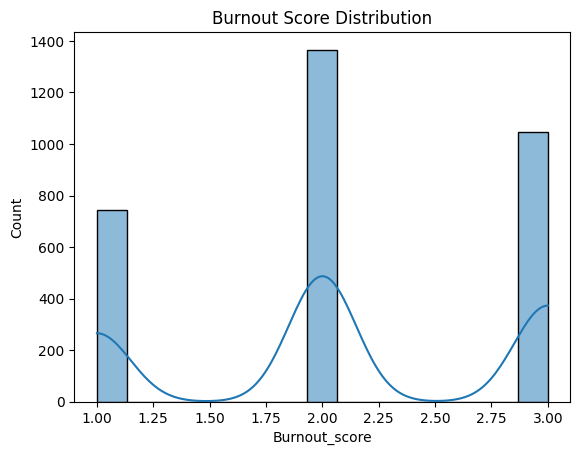

In [20]:
sns.histplot(df['Burnout_score'], kde=True)
plt.title("Burnout Score Distribution")
plt.show()

# Insight:
Most employees fall into medium burnout levels, with a significant number also experiencing high burnout.

This indicates that burnout is a common issue across the workforce and not limited to a small group.

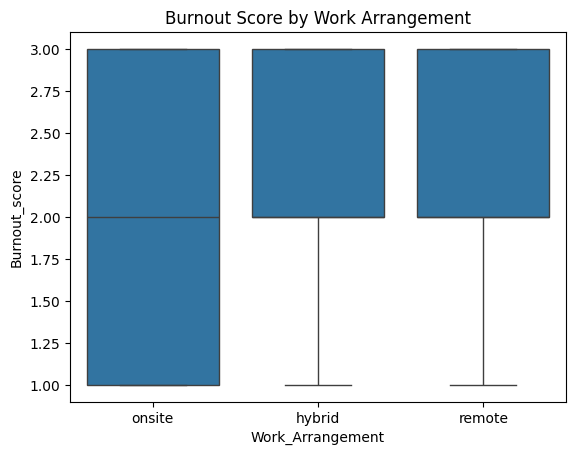

In [22]:
#burnout by work arrangement
sns.boxplot(x='Work_Arrangement', y='Burnout_score', data=df)
plt.title("Burnout Score by Work Arrangement")
plt.show()

# Insight:
On-site workers show greater variability and slightly higher burnout levels compared to remote and hybrid workers.

This suggests that flexible work arrangements may help reduce or stabilize employee burnout.

In [26]:
#ANOVA(Analysis of Variance)
#We use ANOVA because we are comparing burnout scores across more than two groups (remote, hybrid, onsite) to check if the differences are statistically significant.

remote = df[df['Work_Arrangement']=='remote']['Burnout_score']
hybrid = df[df['Work_Arrangement']=='hybrid']['Burnout_score']
onsite = df[df['Work_Arrangement']=='onsite']['Burnout_score']

f_stat, p_value = f_oneway(remote, hybrid, onsite)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 59.2786886061361
P-value: 5.341450638051907e-26


## Results

An ANOVA test was conducted to examine differences in burnout across work arrangements.

- F-statistic: 59.28  
- P-value: < 0.001  


The very low p-value (< 0.001) indicates a statistically significant difference in burnout across work types.

This confirms that work arrangement plays an important role in influencing employee burnout.

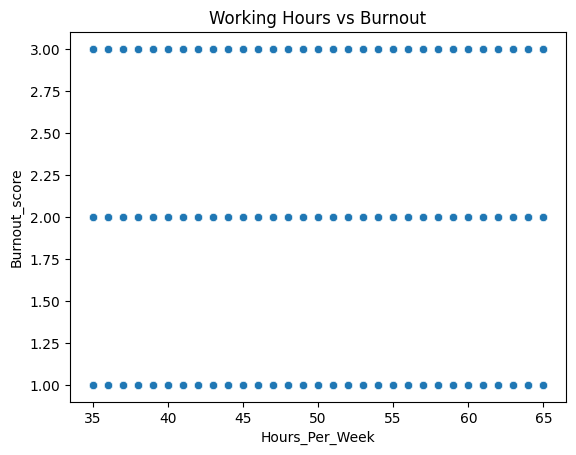

In [29]:
sns.scatterplot(x='Hours_Per_Week', y='Burnout_score', data=df)
plt.title("Working Hours vs Burnout")
plt.show()

# Insight:
There is no strong visible relationship between working hours and burnout levels.

This suggests that burnout may be influenced more by work conditions than simply the number of hours worked.

In [28]:
corr = df[['Burnout_score','Hours_Per_Week','Work_Life_Balance_Score','Social_Isolation_Score']].corr()
print("\nCorrelation Matrix:\n", corr)


Correlation Matrix:
                          Burnout_score  Hours_Per_Week  \
Burnout_score                 1.000000       -0.011599   
Hours_Per_Week               -0.011599        1.000000   
Work_Life_Balance_Score      -0.017843       -0.014879   
Social_Isolation_Score        0.043462       -0.003941   

                         Work_Life_Balance_Score  Social_Isolation_Score  
Burnout_score                          -0.017843                0.043462  
Hours_Per_Week                         -0.014879               -0.003941  
Work_Life_Balance_Score                 1.000000               -0.004639  
Social_Isolation_Score                 -0.004639                1.000000  


# Insight:
Burnout has very weak correlation with working hours and work-life balance,
but shows a slight positive relationship with social isolation.

This indicates that psychological and social factors may contribute more to burnout.

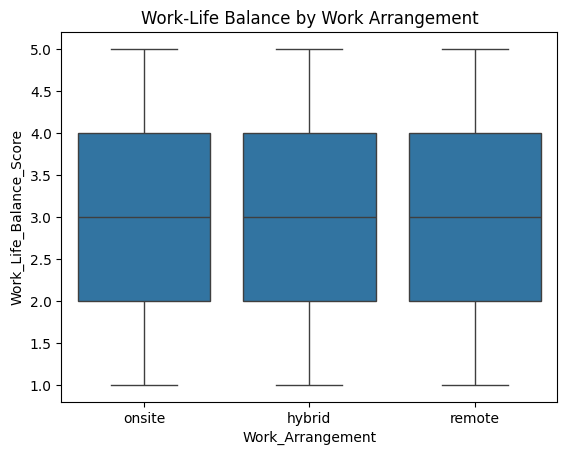

In [30]:
sns.boxplot(x='Work_Arrangement', y='Work_Life_Balance_Score', data=df)
plt.title("Work-Life Balance by Work Arrangement")
plt.show()

# Insight:
Work-life balance scores appear relatively similar across remote, hybrid, and on-site work arrangements.

This suggests that work-life balance depends on factors beyond just the type of work arrangement.

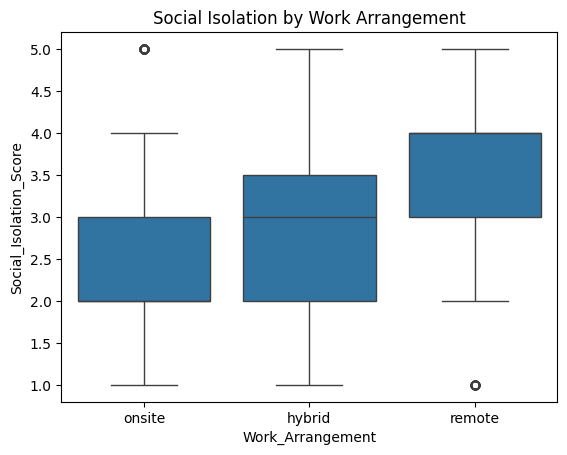

In [31]:
sns.boxplot(x='Work_Arrangement', y='Social_Isolation_Score', data=df)
plt.title("Social Isolation by Work Arrangement")
plt.show()

# Insight:
Remote workers tend to experience higher social isolation compared to hybrid and on-site workers.

This highlights a potential downside of remote work despite its benefits in reducing burnout.

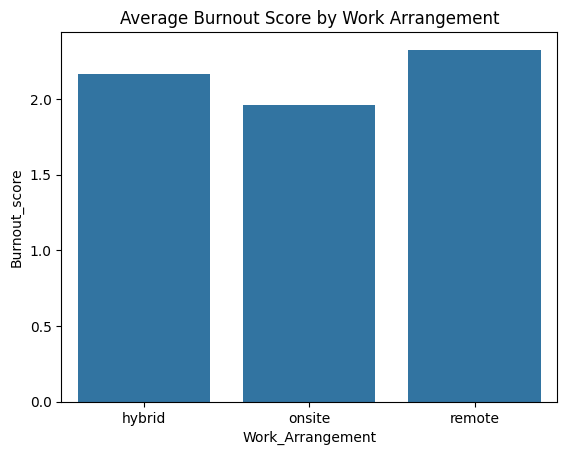

In [32]:
#final summary
summary = df.groupby('Work_Arrangement')['Burnout_score'].mean().reset_index()

sns.barplot(x='Work_Arrangement', y='Burnout_score', data=summary)
plt.title("Average Burnout Score by Work Arrangement")
plt.show()

In [33]:
print("Key Insight: Work arrangement significantly affects burnout, while social isolation increases in remote work.")

Key Insight: Work arrangement significantly affects burnout, while social isolation increases in remote work.
